## **7 Exercise.**

### **Implement an End to End CNN Model for Image Classification Task.**

Objective

In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon using TensorFlow and Keras.

## **Task 1: Data Understanding and Visualization:**

Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:

 • Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

• Expected Output:

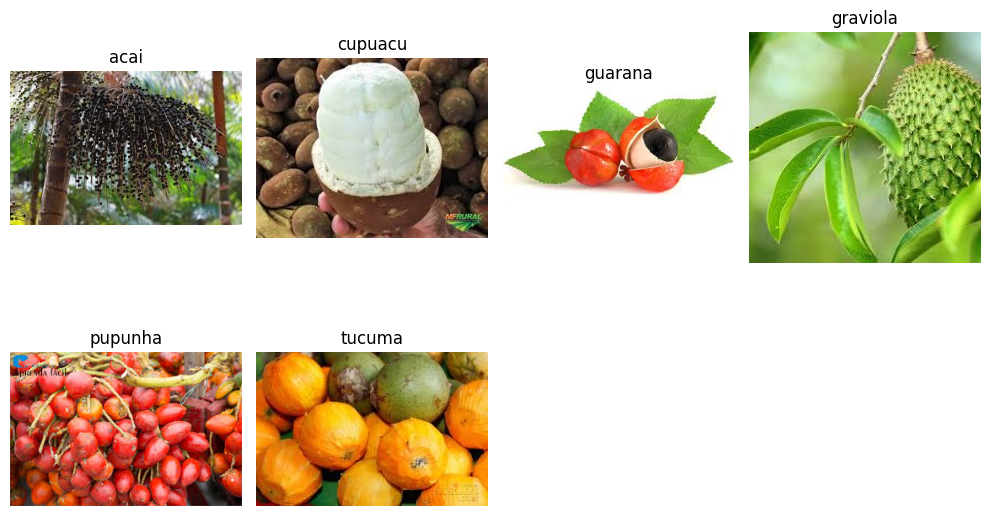

In [5]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to dataset
train_dir = "/content/drive/MyDrive/AI & ML/Data/FruitinAmazon/FruitinAmazon/test"

# Get class names (subfolders)
classes = os.listdir(train_dir)

images = []
labels = []

# Pick one random image from each class
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# Plot images (2 rows)
plt.figure(figsize=(10, 6))
for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## **2. Check for Corrupted Image:**

Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

## **• Hint:**
– Iterate through each class subdirectory and check if each image is valid.

– Use the Image.open() function to attempt to load each image.

– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".

– Maintain a list of all corrupted image paths for reporting.

• Expected Output: No corrupted images found.

In [2]:
import os
from PIL import Image

# Ensure train_data_dir is defined from the previous cell
# If you run this cell independently, uncomment and set the path:
# train_data_dir = '/content/drive/MyDrive/AI & ML/Data/FruitinAmazon/FruitinAmazon/test'

corrupted_images_found = []

if not os.path.exists(train_data_dir):
    print(f"Error: The directory '{train_data_dir}' does not exist. Please check the path.")
else:
    print(f"Checking for corrupted images in: {train_data_dir}")
    for class_name in os.listdir(train_data_dir):
        class_path = os.path.join(train_data_dir, class_name)

        if os.path.isdir(class_path):
            for image_file in os.listdir(class_path):
                image_path = os.path.join(class_path, image_file)

                if os.path.isfile(image_path) and image_file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    try:
                        with Image.open(image_path) as img:
                            img.verify() # Verify the image content
                    except (IOError, SyntaxError) as e:
                        print(f"Removed corrupted image: {image_path} (Error: {e})")
                        os.remove(image_path)
                        corrupted_images_found.append(image_path)
                    except Exception as e:
                        print(f"An unexpected error occurred with image {image_path}: {e}")

    if not corrupted_images_found:
        print("No Corrupted Images Found.")
    else:
        print(f"Total corrupted images removed: {len(corrupted_images_found)}")


Checking for corrupted images in: /content/drive/MyDrive/AI & ML/Data/FruitinAmazon/FruitinAmazon/test
No Corrupted Images Found.


## **Task 2: Loading and Preprocessing Image Data in keras:**

In [6]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.
Using 24 files for training.
Found 30 files belonging to 6 classes.
Using 6 files for validation.


## **Task 3 - Implement a CNN with**

Follow the following Structure and Hyper - parameters:

### **Convolutional Architecture:**

**• Convolutional Layer 1:**

– Filter Size (F): (3, 3)

– Number of Filters (k): 32

– Padding (P): same

– Stride (s): 1

• **Activation Layer**: ReLU activation

• **Pooling Layer 1**: Max pooling

– Filter Size (F): (2, 2)

– Stride (s): 2

**• Convolutional Layer 2:**

– Filter Size (F): (3, 3)

– Number of Filters (k): 32

– Padding (P): same

– Stride (s): 1

**• Activation Layer**: ReLU activation

**• Pooling Layer 2**: Max pooling

– Filter Size (F): (2, 2)

– Stride (s): 2

### **Fully Connected Network Architecture:**

**• Flatten Layer:** Flatten the input coming from the convolutional layers

**• Input Layer:**

**• Hidden Layer - 2**:

– Number of Neurons: 64

– Number of Neurons: 128

**• Output Layer:**

– Number of Neurons: num classes (number of output classes)

In [7]:
from tensorflow.keras import layers, models

num_classes = len(os.listdir(train_dir))

model = models.Sequential([
    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **Task 4: Compile the Model**

**Model Compilation**

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

## **Task 4: Train the Model**

**Model Training**

• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
from tensorflow.keras.callbacks
import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.h5",
                             monitor='val_accuracy',
                             save_best_only=True)

early_stop = EarlyStopping(patience=10,
                           restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1667 - loss: 1.7932

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1667 - loss: 1.7932 - val_accuracy: 0.1667 - val_loss: 2.3974
Epoch 2/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.2083 - loss: 2.0022 - val_accuracy: 0.0000e+00 - val_loss: 1.8452
Epoch 3/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.2083 - loss: 2.0432

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.2083 - loss: 2.0432 - val_accuracy: 0.3333 - val_loss: 1.7438
Epoch 4/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step - accuracy: 0.2083 - loss: 1.6468 - val_accuracy: 0.1667 - val_loss: 1.6203
Epoch 5/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step - accuracy: 0.3750 - loss: 1.3825 - val_accuracy: 0.1667 - val_loss: 1.8084
Epoch 6/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.5000 - loss: 1.2827 - val_accuracy: 0.1667 - val_loss: 1.7789
Epoch 7/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.6667 - loss: 1.1836 - val_accuracy: 0.1667 - val_loss: 1.5081
Epoch 8/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step - accuracy: 0.7917 - loss: 1.0068 - val_accuracy: 0.3333 - val_loss: 1.2159
Epoch 9/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.8333 - loss: 0.8238

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step - accuracy: 0.8333 - loss: 0.8238 - val_accuracy: 0.8333 - val_loss: 0.7954
Epoch 10/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step - accuracy: 0.9583 - loss: 0.6616 - val_accuracy: 0.8333 - val_loss: 0.5125
Epoch 11/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 1.0000 - loss: 0.5138 - val_accuracy: 0.8333 - val_loss: 0.4150
Epoch 12/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 1.0000 - loss: 0.3503 - val_accuracy: 0.8333 - val_loss: 0.5150
Epoch 13/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 1.0000 - loss: 0.2205 - val_accuracy: 0.8333 - val_loss: 0.6112
Epoch 14/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 1.0000 - loss: 0.1499 - val_accuracy: 0.8333 - val_loss: 0.4414
Epoch 15/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 1.0000 - loss: 0.0954 - val_accuracy: 0.8333 - val_loss: 0.2016
Epoch 16/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 1.0000 - loss: 0.0536

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step - accuracy: 1.0000 - loss: 0.0536 - val_accuracy: 1.0000 - val_loss: 0.0827
Epoch 17/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 1.0000 - loss: 0.0350 - val_accuracy: 1.0000 - val_loss: 0.0528
Epoch 18/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 1.0000 - loss: 0.0236 - val_accuracy: 1.0000 - val_loss: 0.0686
Epoch 19/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 1.0000 - loss: 0.0131 - val_accuracy: 0.8333 - val_loss: 0.1325
Epoch 20/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 0.8333 - val_loss: 0.2515
Epoch 21/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.8333 - val_loss: 0.4107
Epoch 22/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.8333 - val_loss: 0.5835
Epoch 23/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.8333 - val_lo

## **Task 5: Evaluate the Model**

**Model Evaluation**

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [10]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.0528
Test Accuracy: 1.0
Test Loss: 0.0527716726064682


## **Task 6: Save and Load the Model**

**Model Saving and Loading**

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [11]:
# Save
model.save("final_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.h5")

# Evaluate again
loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 1.0000 - loss: 0.0528


[0.0527716726064682, 1.0]

## **Task 7: Predictions and Classification Report**

**Making Predictions**

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.

**Expected Deliverables**

**• Code Implementation:** Complete code for building, training, evaluating, saving, and loading
the model.

**• Visualization:** Graphs showing the training and validation loss and accuracy.

**• Classification Report:** Display the final Classification Report on test data.

**• Saved Model:** Submit the saved .h5 model file.

In [12]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = loaded_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
              precision    recall  f1-score   support

           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



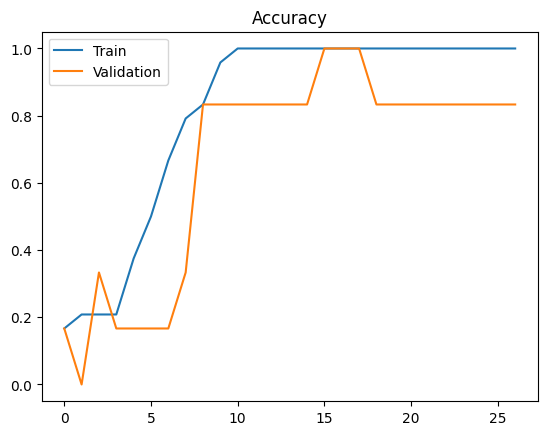

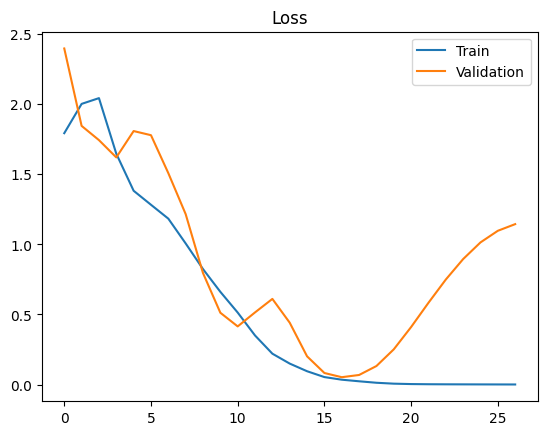

In [13]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()